# Subsample JEPA

```text
Stage 1  subsample-invariance pretraining   (pretrain_epochs)
   |     E(S_A) ~= sg(E(S_B))  for two subsamples of ONE function's cloud
   |     trains the T-Net encoder only
   v
Stage 2  CE-only fine-tuning                (FINETUNE_EPOCHS)
   |
   v
       greedy decode + symbolic evaluation
```

## The objective

For two random subsamples \(S_A, S_B\) drawn from the same function's point
cloud, ask only that the encoder map them to the same latent:

\[ E(S_A) \approx \operatorname{sg}(E(S_B)) \]

No symbolic target, no predictor MLP, no `[PRED]` tokens. This is deliberately
the simplest subsample representation-alignment objective there is: the sole
claim being tested is that invariance to *which points you happen to observe*
is a useful prior for the encoder.

## The comparison

| run | Stage 1 |
|---|---|
| `pretrain_0` | skipped — plain CE training, the baseline |
| `pretrain_10` | 10 epochs of subsample-invariance pretraining |

Paired over seeds `42, 123, 7`.


## 0. Colab / environment setup

The repository is checked out on Drive.

If library code changes while this runtime is live, restart the kernel before
relying on the new imports.

In [ ]:
import os
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

# Edit these two if your Drive layout differs.
DRIVE_BASE = Path('/content/drive/MyDrive/Symba')
REPO_URL = 'https://github.com/zzpDavid2/symbolic-jepa.git'


def sh(cmd: str) -> int:
    """Run a shell command and echo it. Returns the exit code."""
    print(f'$ {cmd}')
    code = os.system(cmd)
    if code != 0:
        print(f'  -> exit {code}')
    return code


DRIVE_MOUNTED = False
if IN_COLAB:
    from google.colab import drive

    try:
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
    except Exception as e:
        # Drive is a durable-backup convenience, not a training requirement.
        print(f'[backup WARNING] Drive mount failed: {type(e).__name__}: {e}')
        print('Training can still run; checkpoints stay on /content only.')

    REPO_DIR = DRIVE_BASE / 'symbolic-jepa'
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        sh(f'git clone {REPO_URL} "{REPO_DIR}"')
    else:
        sh(f'git -C "{REPO_DIR}" pull --ff-only')

    # Do NOT blanket-install sympy: Colab preinstalls it (torch depends on
    # it), and pip replacing it under a live kernel leaves the already-imported
    # module object stale. `torch.utils._sympy.functions` is imported LAZILY, so
    # the mismatch does not surface at setup — it surfaces mid-training as
    # `AttributeError: module 'sympy' has no attribute 'core'`.
    _missing = []
    for _mod in ('sympy', 'scipy'):
        try:
            __import__(_mod)
        except ImportError:
            _missing.append(_mod)
    if _missing:
        sh(f'{sys.executable} -m pip install -q {" ".join(_missing)}')
        print(f'\n[SETUP] installed {_missing} — RESTART THE RUNTIME NOW '
              f'(Runtime > Restart session), then re-run.')
    else:
        print('sympy / scipy already present — not reinstalling')
else:
    REPO_DIR = Path.cwd()

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))

import symbolic_jepa  # noqa: E402

print(f'\nEnvironment : {"Colab" if IN_COLAB else "local"}')
print(f'Repo        : {REPO_DIR}')
print(f'symbolic_jepa imported from: {symbolic_jepa.__file__}')
sh(f'git -C "{REPO_DIR}" rev-parse --short HEAD')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
$ git -C "/content/drive/MyDrive/Symba/symbolic-jepa" pull --ff-only
sympy / scipy already present — not reinstalling

Environment : Colab
Repo        : /content/drive/MyDrive/Symba/symbolic-jepa
symbolic_jepa imported from: /content/drive/MyDrive/Symba/symbolic-jepa/symbolic_jepa/__init__.py
$ git -C "/content/drive/MyDrive/Symba/symbolic-jepa" rev-parse --short HEAD


0

## 1. Imports and global config

Every experiment-defining constant lives in this one cell. `make_run_config`
(section 6) serialises them into each checkpoint, so a checkpoint written
under different settings cannot be reused.

In [ ]:
import datetime
import gc
import hashlib
import json
import random
import time

import numpy as np
import torch
# Imported eagerly: torch defers `torch.utils._sympy.functions` until something
# deep in training needs it, so a torch/sympy mismatch would otherwise detonate
# mid-run rather than here.
import sympy.core                     # noqa: F401
import torch.utils._sympy.functions   # noqa: F401
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

from symbolic_jepa import (
    PrefixTokenizer,
    TNet, SymbolicTransformer,
    subsample_consistency_loss,
    teacher_forced_counts,
    evaluate_predictions,
    view_consistency_diagnostics, generate_diagnostic_embeddings,
)
from symbolic_jepa.datacache import (
    DataCache, cached_prefix_tree,
)
from symbolic_jepa.templates import (
    AUGMENTATION_VERSION, ConstantSampler, build_multiview_template_splits,
    load_template_dataset, templates_fingerprint,
    canonical_split_report, describe_realizations, audit_constant_sampling,
)
from symbolic_jepa.agreement import compare_runs, load_run_matrix
from symbolic_jepa.checkpointing import (
    CheckpointError,
    validate_checkpoint, save_checkpoint_atomic, save_json_atomic,
    load_local_or_restore,
    backup_checkpoint_to_drive, check_best_latest_consistency,
    write_manifest, sync_local_runs_to_drive,
)
from symbolic_jepa.tokenizer import prefix_to_sympy

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
# ── Experiment identity ────────────────────────────────────────────────
# Subsample-invariance pretraining on the corrected v2 pipeline.
#
# Stage 1 replaces the equation-token JEPA objective with the simplest
# subsample-alignment objective: for two random subsamples S_A, S_B of the SAME
# function's point cloud,
#
#     E(S_A)  ~=  sg( E(S_B) )
#
# No predictor MLP, no symbolic target, no [PRED] tokens. The only thing being
# asked of the encoder is invariance to WHICH points of a function it sees.
#
# Everything downstream — splits, Stage-2 CE fine-tuning, checkpointing,
# decoding, evaluation — is byte-identical to jepa_pretrain_v2_vocab40_matched,
# so `pretrain_0` here and `pretrain_0` there differ only by which Stage-1
# objective was skipped.
# constant_aug_v1: the training set stores canonical structures and resamples
# their coefficients per __getitem__, with all views of one item sharing one
# realisation. Weights are shape-compatible with subsample_jepa_v2's, so only a
# distinct EXPERIMENT_VERSION keeps one from being resumed into this run;
# run_config additionally carries every constant-sampling setting, the
# augmentation version and the template fingerprint.
EXPERIMENT_VERSION = 'subsample_constant_aug_v1'

# Bump when DECODING or SCORING changes, independently of training. Trained
# checkpoints stay valid; only metrics.json is invalidated, so affected runs
# are re-scored rather than retrained. Shared with the baseline: identical
# decoder and identical scorer.
EVAL_VERSION = 'v3_expanded_numerics'

# ── Model / optimisation (unchanged from v1) ───────────────────────────
MAX_VARS = 1                  # univariate synthetic data
D_INPUT = MAX_VARS + 1        # (x, y) = 2
N_POINTS = 1000
MAX_SEQ = 64
D_MODEL = 512
N_HEADS = 8
N_LAYERS = 4
DROPOUT = 0.2

LR = 3e-4
WEIGHT_DECAY = 0.1
BATCH = 16
VAL_EVERY = 1
USE_AMP = True

# ── The comparison ─────────────────────────────────────────────────────
# v1 swept {0, 5, 10, 15}; v2 establishes the corrected baseline for the
# 0-vs-10 comparison, paired by seed. Add values back here to widen the sweep.
FINETUNE_EPOCHS = 30
PRETRAIN_EPOCHS_VALUES = [0, 10]
SEEDS = [42, 123, 7]
GLOBAL_SEED = SEEDS[0]        # notebook-level RNG; per-run seeds come from SEEDS

# ── Subsample objective used in Stage 1 ────────────────────────────────
# 'centered' subtracts each view's batch mean before the cosine. Use it. The
# T-Net max-pools ReLU features into the positive orthant, so RAW cosine
# between any two embeddings starts ~0.99 and the raw loss starts ~5e-4 — too
# small to produce gradient. Worse, the raw objective is *minimised* by total
# collapse (all-equal embeddings drive it to 0), whereas the centered one
# *penalises* collapse (drives it to 1).
SUBSAMPLE_LOSS = 'centered'   # 'centered' (recommended) | 'cosine'
# The mode we do NOT optimise, logged alongside for reference: free to compute
# and it shows how the two scales move relative to each other.
SUBSAMPLE_LOSS_OTHER = 'cosine' if SUBSAMPLE_LOSS == 'centered' else 'centered'
PRETRAIN_STOPGRAD = True      # E(S_A) ~= sg(E(S_B)); see the note in section 7

N_VIEWS = 2                   # subsamples per equation per step
POOL_MULT = 4                 # draw N_POINTS*POOL_MULT, then subsample views
VIEW_POINTS = None            # points per view (None = N_POINTS)
# TRAIN_VIEW_SEED and FINETUNE_VIEW_EPOCH_OFFSET are gone. Views now derive
# from (run seed, STAGE, epoch, idx, view), and `stage` is what keeps Stage 2
# from replaying the exact clouds Stage 1 pretrained on — a named separation
# rather than an epoch offset large enough to hope for no collision.

# ── Fixed view-consistency diagnostic ──────────────────────────────────
# Same clouds for every checkpoint and every model, so reported differences
# reflect the encoder rather than the data.
EVAL_SEED = 2718
DIAG_N_EXPRS = 256            # val equations used for the diagnostic
DIAG_N_VIEWS = 4              # views per equation

# ── Data ───────────────────────────────────────────────────────────────
# Canonical forms come from data/synthetic_templates.pkl, built once by
#   python tools/build_template_dataset.py --max-expressions 200000 --max-vars 1
# from the same 200 000 raw strings, with the same filters and in the same
# order — so the split matches subsample_jepa_v2's exactly.
TEMPLATE_PKL = str(REPO_DIR / 'data' / 'synthetic_templates.pkl')
SYNTH_PKL = str(REPO_DIR / 'data' / 'synthetic.pkl')   # source of the above
SYNTH_SEED = 42
MAX_SYNTH = 200_000           # raw strings the template file was built from
DEDUPE_BY_TOKENS = True       # one template per distinct token sequence
USE_DATA_CACHE = True         # reuse the branch tree
GROUP_BY_TOKENS = True        # no canonical form spans two splits

# ── Dynamic constant augmentation ──────────────────────────────────────
# Composes with the multi-view objective rather than replacing it:
#
#   sample constants -> one function
#         |
#         +-- pool of N_POINTS*POOL_MULT points
#               +-- view 0 ... view N_VIEWS-1     (same function)
#
# All views of one item share ONE coefficient draw. Views must differ in which
# points were observed, not in which function was observed, or the consistency
# objective is trained against a false premise.
DYNAMIC_CONSTANTS = True

# 'global': every coefficient of every form draws its MAGNITUDE from one shared
# pool fitted on the training forms only, so a form's coefficients cannot
# identify it. Sign comes from the reference because sign is structural.
CONSTANT_MODE = 'global'
CONSTANT_LOG_SPREAD = 2.0
CONSTANT_JITTER = 1.0
CONSTANT_MAX_TRIES = 8
CONSTANT_MAX_ABS = 1e6

# Every realisation is a pure function of (run seed, stage, epoch, idx), so
# worker count, worker scheduling, process restart and checkpoint resume cannot
# change what an example sees. Resuming is then scientifically equivalent to
# never having interrupted. The base seed is bound to the RUN seed in train_one.
DETERMINISTIC_AUGMENTATION = True
CONSTANT_SEED = SEEDS[0] if DETERMINISTIC_AUGMENTATION else None

# ── DataLoader ─────────────────────────────────────────────────────────
# Workers fork from identical NumPy/Python RNG state and would emit identical
# augmented clouds; `seed_worker` (section 2) fixes that. Set to 0 to move
# sampling back into the main process — that also makes Stage 2's augmentation
# stream reset per epoch, so pre0 and pre10 see bit-identical clouds (see the
# trajectory note in section 2).
NUM_WORKERS = 2

# ── Evaluation ─────────────────────────────────────────────────────────
MAX_EVAL_EXAMPLES = 0         # 0 = full test set; a positive N caps greedy decode

# Symbolic metrics DURING training, so the advantage can be read as a curve
# rather than one end-of-run number. COST: SYMBOLIC_EVAL_N greedy decodes plus
# an ~11-parameter BFGS fit each, every SYMBOLIC_EVAL_EVERY epochs.
# Set SYMBOLIC_EVAL_EVERY = 0 to switch it off.
SYMBOLIC_EVAL_EVERY = 5
SYMBOLIC_EVAL_N = 128

# ── Drive backup cadence ───────────────────────────────────────────────
DRIVE_BACKUP_EVERY = 5        # epochs between latest.pt backups

## 2. Reproducibility / worker seeding

Three separate mechanisms, deliberately:

* `seed_everything(seed)` — full re-seed of torch/numpy/python.
* `seed_worker` — the mentor's fix. Without it, forked DataLoader workers
  inherit identical NumPy/Python state and emit identical point clouds. It is
  epoch-independent: each worker is seeded once from `torch.initial_seed()`.
* `stage1_epoch_seed` / `stage2_epoch_seed` — the per-epoch reseed of the
  *main-process* RNG and of the sampler's `torch.Generator`. These depend only
  on `(seed, epoch)`, never on how much RNG an earlier stage consumed, so
  epoch *N* is identical whether the run was uninterrupted or resumed straight
  into epoch *N*, and every `pretrain_epochs` condition at a given seed shares
  one Stage-2 trajectory.

**Caveat with `NUM_WORKERS > 0`:** worker processes are persistent and are
seeded once, so their augmentation stream is *not* reset per epoch. A
`pretrain_epochs=10` run therefore consumes worker-side draws during Stage 1
and enters Stage 2 on different clouds than the `0` baseline. Shuffle order,
dropout, and initialisation remain matched. Set `NUM_WORKERS = 0` if you want
the clouds matched too.

In [ ]:
def seed_everything(seed: int) -> None:
    """Full re-seed for reproducibility."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def seed_worker(worker_id: int) -> None:
    """Give every DataLoader worker its own NumPy/Python stream."""
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed + worker_id)
    random.seed(worker_seed + worker_id)


def stage1_epoch_seed(seed: int, epoch: int) -> int:
    """RNG seed for one subsample-pretraining epoch."""
    return seed + 200_000 + epoch


def stage2_epoch_seed(seed: int, epoch: int) -> int:
    """RNG seed for one CE fine-tuning epoch."""
    return seed + 100_000 + epoch


def make_train_loader(dataset, seed: int):
    """Training loader: shuffled, multi-worker, explicitly seeded.

    Returns `(loader, generator)`. Re-seed the generator with
    `g.manual_seed(epoch_seed)` before each epoch — the sampler re-reads it on
    every `__iter__`, so the shuffle order stays a pure function of
    `(seed, epoch)` even with persistent workers.
    """
    g = torch.Generator()
    g.manual_seed(seed)
    loader = DataLoader(
        dataset,
        batch_size=BATCH,
        shuffle=True,
        num_workers=NUM_WORKERS,
        # MUST stay False. MultiViewPointCloudDataset reads `self.epoch`
        # inside __getitem__, and workers hold a FORKED COPY of the dataset —
        # persistent workers would never observe the epoch bump and every
        # epoch's views would silently freeze at epoch 0.
        persistent_workers=False,
        pin_memory=(DEVICE == 'cuda'),
        worker_init_fn=seed_worker,
        generator=g,
    )
    return loader, g


def symbolic_eval_subset(model, dataset, n=None):
    """Greedy-decode the first *n* examples of *dataset* and score them.

    `evaluate_predictions` pairs predictions to `dataset.samples[i]` by
    POSITION, so decoding a prefix in order is all that is needed — a `Subset`
    wrapper would hide `.samples` and break that pairing. A fixed prefix is
    comparable across epochs, arms and seeds without another seed to carry.
    """
    n = min(n or SYMBOLIC_EVAL_N, len(dataset))
    loader = DataLoader(Subset(dataset, range(n)), batch_size=BATCH,
                        shuffle=False, num_workers=0)

    was_training = model.training
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            points = batch['points'].to(DEVICE, non_blocking=True)
            out = model.generate(points, tokenizer, max_new_tokens=MAX_SEQ)
            for j, pred_str in enumerate(out):
                preds.append(
                    (tokenizer.decode(batch['input_ids'][j].tolist()), pred_str))
    if was_training:
        model.train()

    res = evaluate_predictions(preds, dataset, tokenizer)
    return {
        'n': n,
        'exact': res['exact_match'],
        'equiv': res['algebraic_equiv'],
        'r2_above_0.9': res['r2_above_0.9'],
        'mean_r2': res['mean_r2'],
    }


def make_eval_loader(dataset):
    """Deterministic loader for validation / test: no shuffle, no workers.

    `evaluate_predictions` indexes `dataset.samples[i]` positionally, so the
    order must be the dataset's own.
    """
    return DataLoader(dataset, batch_size=BATCH, shuffle=False, num_workers=0)


# Representation diagnostic: same-function vs different-function cosine on a
# FIXED set of views, not on whichever validation batch arrived first.
#
# `generate_diagnostic_embeddings` seeds every cloud from
# (EVAL_SEED, 0, expr_idx, view_idx), so the SAME clouds are encoded for every
# epoch, every pretraining condition and every model seed — a change in the
# reported numbers is a change in the encoder, never in the data. This is the
# direct read on the Stage-1 objective: subsample invariance should raise
# same_fn_cos without dragging diff_fn_cos up with it.
#
# Read the *_centered numbers. The T-Net max-pools ReLU activations into the
# positive orthant, so raw cosine between ANY two embeddings sits near 0.98
# regardless of content; centering strips that shared offset. `gap_centered`
# (same - diff) is the headline: it is high only when the encoder is both
# subsample-invariant AND still discriminating between functions, so it cannot
# be gamed by collapse the way same_fn_cos alone can.


def view_consistency(model, val_ds, n_exprs: int = DIAG_N_EXPRS,
                     n_views: int = DIAG_N_VIEWS):
    """same/diff-function cosine on the fixed diagnostic views."""
    z = generate_diagnostic_embeddings(
        val_ds, model.encoder, n_exprs=n_exprs, n_views=n_views,
        eval_seed=EVAL_SEED, device=DEVICE, batch_size=BATCH,
    )
    return view_consistency_diagnostics(z, n_views)


seed_everything(GLOBAL_SEED)
print(f'Global seed: {GLOBAL_SEED} | DataLoader workers: {NUM_WORKERS}')

Global seed: 42 | DataLoader workers: 2


## 3. Tokenizer and canonical templates

Deduplication is done offline with:

```bash
python tools/build_template_dataset.py \
    --input data/synthetic.pkl --output data/synthetic_templates.pkl \
    --max-expressions 200000 --max-vars 1
```

In [ ]:
# Derived-artifact cache. Parsing the pickle is the slow step and its result
# depends only on the settings above, so it is cached content-addressed: the
# filename embeds a hash of the source pickle, every argument that changes
# which expressions survive, the tokenizer vocabulary, and the source of the
# parsing modules. A changed config or a changed parser misses and rebuilds
# under a new name — a stale entry cannot be read.
if IN_COLAB:
    LOCAL_CACHE_ROOT = Path('/content/symbolic_jepa_cache')
    DRIVE_CACHE_ROOT = (DRIVE_BASE / 'symbolic_jepa_cache') if DRIVE_MOUNTED else None
else:
    LOCAL_CACHE_ROOT = REPO_DIR / 'local_runs' / 'symbolic_jepa_cache'
    DRIVE_CACHE_ROOT = None

CACHE = DataCache(LOCAL_CACHE_ROOT, DRIVE_CACHE_ROOT, enabled=USE_DATA_CACHE)
print(f'data cache local : {LOCAL_CACHE_ROOT}')
print(f'data cache drive : {DRIVE_CACHE_ROOT}')

data cache local : /content/symbolic_jepa_cache
data cache drive : /content/drive/MyDrive/Symba/symbolic_jepa_cache


In [ ]:
tokenizer = PrefixTokenizer(max_vars=MAX_VARS)
print(f'Vocab size: {len(tokenizer)}')

print(f'Loading synthetic expressions from {SYNTH_PKL} ...')
# `data/` is gitignored, so a fresh clone has neither file. On Colab both live
# in the Drive-resident repo. Build the template file once if it is missing.
if not Path(TEMPLATE_PKL).exists():
    print(f'{TEMPLATE_PKL} not found — building from {SYNTH_PKL} '
          f'(~11 min, one time)')
    import pickle as _pickle

    from symbolic_jepa.templates import (
        build_templates_from_strings, save_template_dataset,
    )

    _tok = PrefixTokenizer(max_vars=MAX_VARS)
    with open(SYNTH_PKL, 'rb') as _f:
        _raw = _pickle.load(_f)[:MAX_SYNTH]
    _tmpls, _stats = build_templates_from_strings(
        _raw, _tok, max_seq_len=MAX_SEQ, progress=True)
    save_template_dataset(TEMPLATE_PKL, _tmpls, _tok, meta=dict(
        _stats, source_pkl=Path(SYNTH_PKL).name, max_expressions=MAX_SYNTH,
        max_seq_len=MAX_SEQ, max_vars=MAX_VARS, seed=SYNTH_SEED))
    del _raw, _tmpls

templates, template_meta = load_template_dataset(TEMPLATE_PKL, tokenizer)
print(f'  {len(templates)} canonical forms '
      f'(built {template_meta.get("created")} from '
      f'{template_meta.get("max_expressions")} raw strings)')
if template_meta.get('max_expressions') != MAX_SYNTH:
    print(f'\n[WARNING] template file built from '
          f'{template_meta.get("max_expressions")} raw strings but MAX_SYNTH is '
          f'{MAX_SYNTH}; the form set and split differ from the baseline.')

TEMPLATE_FINGERPRINT = templates_fingerprint(templates)
CONSTANT_SAMPLER = ConstantSampler(
    mode=CONSTANT_MODE, log_spread=CONSTANT_LOG_SPREAD,
    jitter=CONSTANT_JITTER)
print(f'  template fingerprint : {TEMPLATE_FINGERPRINT}')
print(f'  augmentation version : {AUGMENTATION_VERSION}')
print(f'  constant sampler     : {CONSTANT_MODE} | '
      f'DYNAMIC_CONSTANTS={DYNAMIC_CONSTANTS} | '
      f'DETERMINISTIC={DETERMINISTIC_AUGMENTATION}')

for expr in templates[:5]:
    print(f'  {expr.prefix}')

Vocab size: 32
Loading synthetic expressions from /content/drive/MyDrive/Symba/symbolic-jepa/data/synthetic.pkl ...
  33704 canonical forms (built 2026-08-15T02:22:17 from 200000 raw strings)
  template fingerprint : 234101c1b21727c8
  augmentation version : stateless-v1
  constant sampler     : global | DYNAMIC_CONSTANTS=True | DETERMINISTIC=True
  mul mul C log add C pow add add add add C mul C x1 mul C pow x1 four mul C pow x1 three mul C pow x1 two two tanh add C mul C x1
  add mul mul C exp mul C pow x1 two sinh mul C x1 mul mul C pow add C mul C x1 neg1 sin add C mul C x1
  mul mul mul C cosh mul C x1 exp mul C pow x1 two exp mul C pow add C x1 two
  add mul mul C pow add C pow add C mul C x1 two neg1 add C mul C x1 mul mul C cosh mul C x1 exp mul C pow x1 two
  mul mul C pow add C mul C x1 neg1 sin add C mul C x1


## 4. Corrected dataset splits and branching prefix tree

`group_by_tokens=True` keeps every expression sharing a prefix token sequence
inside one split, so no held-out sequence appears verbatim in train. The
library prints its own leakage diagnostic — that is the authoritative one and
is not duplicated here.

`BRANCH_TREE` is built **once**, from the finalised training split only. It
maps each token prefix to the number of distinct continuations seen in
training; `teacher_forced_counts(..., branch_tree=BRANCH_TREE)` then scores
only the positions where more than one next token was ever possible.
Ordinary teacher-forced accuracy is dominated by deterministic symbolic
syntax, so it can sit near 100% while the model gets every genuine decision
wrong. Both are reported, always.

The tree is cached too, keyed on a hash of the training token sequences
themselves — so the cached tree is provably the one those sequences produce,
and training and diagnostics cannot drift apart. It is only a few seconds to
build; the cache is there for that guarantee, not for the time.

Not cached: the point-cloud probe inside `build_synthetic_splits`, which
samples every expression once (~2 ms each, ~1 min total). It needs the live
`Expression` objects anyway, so caching it would save little.

In [ ]:
# Train is multi-view; val/test stay deterministic single-view and cached.
# Same split logic, same SYNTH_SEED and same group_by_tokens as
# build_synthetic_splits, so the partition matches the baseline run exactly
# and the two experiments are directly comparable.
synth_train, synth_val, synth_test = build_multiview_template_splits(
    templates, tokenizer,
    n_points=N_POINTS, max_seq_len=MAX_SEQ, max_vars=MAX_VARS,
    seed=SYNTH_SEED,
    n_views=N_VIEWS, pool_mult=POOL_MULT, view_points=VIEW_POINTS,
    dynamic_constants=DYNAMIC_CONSTANTS,
    sampler=CONSTANT_SAMPLER,
    constant_seed=CONSTANT_SEED,
    max_constant_tries=CONSTANT_MAX_TRIES,
    max_abs=CONSTANT_MAX_ABS,
    cache_eval=True,
    group_by_tokens=GROUP_BY_TOKENS,
    progress=True,
)

BRANCH_TREE = cached_prefix_tree(synth_train.token_keys, cache=CACHE,
                                 progress=True)

_train_keys = set(synth_train.token_keys)
print(f'\nDataset summary ({EXPERIMENT_VERSION})')
print(f'  raw expression strings considered : {MAX_SYNTH}')
print(f'  canonical forms in template file  : {len(templates)}')
print(f'  train / val / test                : '
      f'{len(synth_train)} / {len(synth_val)} / {len(synth_test)}')
print(f'  unique token sequences (train)    : '
      f'{synth_train.unique_sequence_count()}')
print(f'  unique token sequences (val/test) : '
      f'{synth_val.unique_sequence_count()} / '
      f'{synth_test.unique_sequence_count()}')
for _name, _ds in (('val', synth_val), ('test', synth_test)):
    _dup = sum(1 for k in _ds.token_keys if k in _train_keys)
    print(f'  leakage {_name:<4} (also in train)      : {_dup}/{len(_ds)}')
print(f'  branch tree prefixes              : {len(BRANCH_TREE)}')
print(f'  branching prefixes (>1 next tok)  : '
      f'{sum(1 for v in BRANCH_TREE.values() if v > 1)}')
print(f'  dynamic constants (train)         : '
      f'{synth_train.dynamic_constants}')
print(f'  deterministic augmentation        : '
      f'{synth_train.deterministic_augmentation}')
print(f'  template fingerprint              : {TEMPLATE_FINGERPRINT}')
print(f'  augmentation version              : {AUGMENTATION_VERSION}')

grouping by canonical form:   0%|          | 0/33704 [00:00<?, ?it/s]

constant sampler fitted on 26963 train forms: global magnitude pool: 950773 values, median 1.057, p90 3.111, p99 9.968, max 11233.5


train point clouds:   0%|          | 0/26963 [00:00<?, ?it/s]

Templates train: 26963 forms (26963 unique canonical, 2 views each, dynamic constants)


val point clouds:   0%|          | 0/3370 [00:00<?, ?it/s]

Templates val: 3370 forms (3370 unique canonical, fixed constants)


test point clouds:   0%|          | 0/3371 [00:00<?, ?it/s]

Templates test: 3371 forms (3371 unique canonical, fixed constants)
  leakage val: 0/3370 (0.0%) sequences also in train
  leakage test: 0/3371 (0.0%) sequences also in train
[cache] hit  branch tree over 26963 train sequences  (restored Drive -> local branch_tree-1a5f8f6c32a1ff25.pkl)

Dataset summary (subsample_constant_aug_v1)
  raw expression strings considered : 200000
  canonical forms in template file  : 33704
  train / val / test                : 26963 / 3370 / 3371
  unique token sequences (train)    : 26963
  unique token sequences (val/test) : 3370 / 3371
  leakage val  (also in train)      : 0/3370
  leakage test (also in train)      : 0/3371
  branch tree prefixes              : 373926
  branching prefixes (>1 next tok)  : 21341
  dynamic constants (train)         : True
  deterministic augmentation        : True
  template fingerprint              : 234101c1b21727c8
  augmentation version              : stateless-v1


In [ ]:
CANONICAL_REPORT = canonical_split_report(synth_train, synth_val, synth_test)

number of canonical train forms: 26963
number of canonical val forms: 3370
number of canonical test forms: 3371
overlap train/val: 0
overlap train/test: 0
overlap val/test: 0


In [ ]:
describe_realizations(synth_train, n_forms=3, n_realizations=3, seed=0)


=== canonical form 1/3 (index 17138, 11 coefficient slots) ===
canonical target:
    mul mul C add add add C mul C pow x1 three mul C pow x1 two mul C x1 log add C pow add add add add C mul C pow x1 four mul C pow x1 two mul C x1 mul C pow x1 three two
reference:
    2.98229*(0.972601*x**3 + 1.28316*x**2 - 0.982472*x - 0.0857599)*log((0.835718*x**4 - 1.96064*x**3 - 0.0960241*x**2 - 0.13779*x - 0.538026)**2 + 1.0)
realization 1:
    1.05868005752563*(1.82465004920959*x**3 + 0.473376989364624*x**2 - 1.20793449878693*x - 1.03954994678497)*log((1.77399003505707*x**4 - 0.473255008459091*x**3 - 0.761627972126007*x**2 - 6.0*x - 2.71150994300842)**2 + 0.201772004365921)
realization 2:
    0.320712000131607*(0.2031230032444*x**3 + 1.33413994312286*x**2 - 0.169346004724503*x - 0.202224001288414)*log((0.215163007378578*x**4 - 0.767907023429871*x**3 - 1.0*x**2 - 0.766059994697571*x - 1.84642004966736)**2 + 5.0)

=== canonical form 2/3 (index 19376, 16 coefficient slots) ===
canonical target:
    

True

In [ ]:
CONSTANT_AUDIT = audit_constant_sampling(synth_train, n=256, seed=0)

constant sampling audit over 256 examples: 7 rejected draws (0.027 per accepted example), 0 fell back to reference coefficients (0.0%)


## 5. Model construction

In [ ]:
def build_model(dropout: float = DROPOUT):
    """Fresh encoder + decoder on DEVICE.

    No predictor: the subsample objective aligns two encoder outputs directly,
    so there is nothing to predict *with*. The return signature keeps a third
    slot for symmetry with the baseline driver, always None.
    """
    encoder = TNet(d_input=D_INPUT, d_model=D_MODEL)
    model = SymbolicTransformer(
        encoder=encoder, vocab_size=len(tokenizer),
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
        d_ff=4 * D_MODEL, max_seq_len=MAX_SEQ,
        dropout=dropout, pad_id=tokenizer.pad_id,
    ).to(DEVICE)

    return model, encoder, None


def make_amp_ctx():
    if USE_AMP and DEVICE == 'cuda':
        return lambda: torch.autocast('cuda', dtype=torch.bfloat16)
    if USE_AMP and DEVICE == 'mps':
        return lambda: torch.autocast('mps', dtype=torch.float16)
    return lambda: torch.amp.autocast('cpu', enabled=False)


amp_ctx = make_amp_ctx()

## 6. Robust checkpoint helpers and paths

### Surviving a lost runtime

```text
Normal live training : /content v2 checkpoint = authoritative
Runtime destroyed    : /content disappears
New runtime          : restore a validated v2 Drive backup -> local /content,
                       then train from the local copy again
During training      : periodically copy already-validated local
                       checkpoints -> Drive
```

### Per-run layout

```text
jepa_pretrain_v2_vocab40_matched_l8/
    pretrain_0/  seed_42/  pretrain/    latest.pt
                           supervised/  latest.pt  best.pt
                                        metrics.json  manifest.json
                                        history.json
    pretrain_10/ seed_42/  ...
```

The `pretrain/` and `supervised/` namespaces are separate *and* their
`run_config` carries a `stage` field, so a pretraining checkpoint can never be
mistaken for a supervised one. `run_config` also carries `pretrain_epochs`,
and every checkpoint carries `seed`, so a `pretrain_epochs=0` run cannot
restore a `10` run and one seed cannot restore another.

In [ ]:
if IN_COLAB:
    LOCAL_CHECKPOINT_ROOT = Path('/content/symbolic_jepa_checkpoints') / EXPERIMENT_VERSION
    LOCAL_LOG_ROOT = Path('/content/symbolic_jepa_runs') / EXPERIMENT_VERSION
    DRIVE_CHECKPOINT_ROOT = (
        (DRIVE_BASE / 'symbolic_jepa_checkpoints') / EXPERIMENT_VERSION
        if DRIVE_MOUNTED else None
    )
else:
    LOCAL_CHECKPOINT_ROOT = REPO_DIR / 'local_runs' / 'symbolic_jepa_checkpoints' / EXPERIMENT_VERSION
    LOCAL_LOG_ROOT = REPO_DIR / 'local_runs' / 'symbolic_jepa_runs' / EXPERIMENT_VERSION
    DRIVE_CHECKPOINT_ROOT = None

LOCAL_CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_LOG_ROOT.mkdir(parents=True, exist_ok=True)

# Files inside one run directory. Nothing outside this map is ever written.
RUN_FILES = {
    'pre_latest': 'pretrain/latest.pt',
    'sup_latest': 'supervised/latest.pt',
    'sup_best': 'supervised/best.pt',
    'metrics': 'supervised/metrics.json',
    'manifest': 'supervised/manifest.json',
    'history': 'supervised/history.json',
}


def run_paths(pretrain_epochs: int, seed: int) -> dict:
    """THE single source of truth for v2 run paths.

    Every checkpoint, metric, manifest and TensorBoard directory derives from
    this — never from a hand-built f-string.
    """
    rel = Path(f'pretrain_{pretrain_epochs}') / f'seed_{seed}'
    paths = {'rel': rel, 'tb': LOCAL_LOG_ROOT / rel,
             'local_dir': LOCAL_CHECKPOINT_ROOT / rel}
    for key, sub in RUN_FILES.items():
        paths[key] = LOCAL_CHECKPOINT_ROOT / rel / sub
        paths[f'drive_{key}'] = (
            None if DRIVE_CHECKPOINT_ROOT is None
            else DRIVE_CHECKPOINT_ROOT / rel / sub
        )
    return paths


print(f'EXPERIMENT_VERSION    : {EXPERIMENT_VERSION}')
print(f'LOCAL_CHECKPOINT_ROOT : {LOCAL_CHECKPOINT_ROOT}   (authoritative)')
print(f'DRIVE_CHECKPOINT_ROOT : {DRIVE_CHECKPOINT_ROOT}   (backup only)')
print(f'LOCAL_LOG_ROOT        : {LOCAL_LOG_ROOT}')
print(f'DRIVE_BACKUP_EVERY    : {DRIVE_BACKUP_EVERY} epochs')
if DRIVE_CHECKPOINT_ROOT is None:
    print('\n[backup WARNING] No Drive root configured — checkpoints are '
          'LOCAL ONLY and will be lost if this runtime dies.')

EXPERIMENT_VERSION    : subsample_constant_aug_v1
LOCAL_CHECKPOINT_ROOT : /content/symbolic_jepa_checkpoints/subsample_constant_aug_v1   (authoritative)
DRIVE_CHECKPOINT_ROOT : /content/drive/MyDrive/Symba/symbolic_jepa_checkpoints/subsample_constant_aug_v1   (backup only)
LOCAL_LOG_ROOT        : /content/symbolic_jepa_runs/subsample_constant_aug_v1
DRIVE_BACKUP_EVERY    : 5 epochs


In [ ]:
def make_run_config(pretrain_epochs: int, stage: str) -> dict:
    """Every setting that materially changes what a run means.

    Stored in each checkpoint and in metrics.json, and compared before anything
    cached is reused. `experiment_version` and `stage` are what make v1
    checkpoints and cross-stage mix-ups structurally impossible.

    `vocab_size`/`vocab_hash` make a tokenizer change structurally impossible
    to miss even if EXPERIMENT_VERSION is not bumped: nothing else here is
    derived from the tokenizer, so a vocabulary edit would otherwise leave
    every field identical and let a stale metrics.json be returned verbatim.
    The hash rather than the size alone catches reorderings and same-count
    token swaps.
    """
    assert stage in ('pretrain', 'supervised')
    return {
        'experiment_version': EXPERIMENT_VERSION,
        'stage': stage,
        'pretrain_epochs': pretrain_epochs,
        'finetune_epochs': FINETUNE_EPOCHS,
        'pretrain_stopgrad': PRETRAIN_STOPGRAD,
        'subsample_loss': SUBSAMPLE_LOSS,
        'n_views': N_VIEWS,
        'pool_mult': POOL_MULT,
        'view_points': VIEW_POINTS,
        # Constant augmentation is part of what a run means, and the last three
        # make a resume against different augmentation or a different
        # canonical-template dataset structurally impossible.
        'dynamic_constants': DYNAMIC_CONSTANTS,
        'constant_mode': CONSTANT_MODE,
        'constant_log_spread': CONSTANT_LOG_SPREAD,
        'constant_jitter': CONSTANT_JITTER,
        'constant_seed': CONSTANT_SEED,
        'constant_max_tries': CONSTANT_MAX_TRIES,
        'constant_max_abs': CONSTANT_MAX_ABS,
        'deterministic_augmentation': DETERMINISTIC_AUGMENTATION,
        'augmentation_version': AUGMENTATION_VERSION,
        'template_fingerprint': TEMPLATE_FINGERPRINT,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'batch': BATCH,
        'dropout': DROPOUT,
        'd_model': D_MODEL,
        'n_heads': N_HEADS,
        'n_layers': N_LAYERS,
        'max_seq': MAX_SEQ,
        'n_points': N_POINTS,
        'max_vars': MAX_VARS,
        'vocab_size': len(tokenizer),
        'vocab_hash': hashlib.sha1(
            '\x00'.join(tokenizer.vocab).encode()).hexdigest()[:12],
        'synth_seed': SYNTH_SEED,
        'max_synth': MAX_SYNTH,
        'dedupe_by_tokens': DEDUPE_BY_TOKENS,
        'group_by_tokens': GROUP_BY_TOKENS,
    }


# Fields the resume path actually reads back, beyond the structural minimum.
LATEST_EXTRA = ('optimizer', 'scheduler', 'history', 'best_val', 'best_epoch')
PRETRAIN_EXTRA = ('optimizer',)


def make_validator(pretrain_epochs, seed, kind, stage, path=None):
    """A one-argument validator for save/load helpers."""
    cfg = make_run_config(pretrain_epochs, stage)
    extra = {'latest': LATEST_EXTRA, 'pretrain': PRETRAIN_EXTRA}.get(kind, ())
    max_epoch = pretrain_epochs if stage == 'pretrain' else FINETUNE_EPOCHS

    def _validate(ck):
        validate_checkpoint(
            ck, expected_seed=seed, expected_run_config=cfg, kind=kind,
            extra_required=extra, max_epoch=max_epoch, path=path,
        )

    return _validate


def backup_and_record(local_path, drive_path, manifest_path, verbose=True) -> bool:
    """Best-effort Drive backup, recorded in the manifest. Never raises."""
    if drive_path is None:
        write_manifest(manifest_path, {
            'last_drive_backup_status': 'skipped (no Drive root)',
        })
        return False
    ok = backup_checkpoint_to_drive(local_path, drive_path, verbose=verbose)
    write_manifest(manifest_path, {
        'last_drive_backup_time': datetime.datetime.now().isoformat(timespec='seconds'),
        'last_drive_backup_status': 'ok' if ok else 'failed',
        'last_drive_backup_file': Path(local_path).name,
    })
    return ok

## 7. JEPA pretraining stage (Stage 1)

Gradient flow is JEPA → encoder only (with `PRETRAIN_STOPGRAD=True`). There is
deliberately **no** decoder forward pass and **no** CE term: the loss is the
bare JEPA objective, and there is no lambda — the swept variable is
`pretrain_epochs`. `pretrain_epochs == 0` skips this stage entirely and is the
control.

Stage 1 is checkpointed under its own `pretrain/` namespace so a lost runtime
does not throw away ten epochs of encoder pretraining. It is skipped when a
valid supervised checkpoint already exists — Stage 1's weights are inside it.

In [ ]:
def run_pretraining(model, predictor, params, pretrain_epochs, seed,
                    paths, writer, train_loader, train_gen, history,
                    train_ds=None):
    """Stage 1: subsample-invariance pretraining. Resumable, local-first.

    Objective, for two random subsamples S_A, S_B of one function's cloud:

        E(S_A)  ~=  sg( E(S_B) )

    Only the encoder is trained — the decoder never sees a gradient here,
    because the loss is a function of encoder outputs alone.
    """
    if pretrain_epochs == 0:
        return

    # Stage 1 gets its OWN optimizer; Stage 2 builds a fresh one so no Adam
    # moments or LR schedule carry across the objective switch.
    pre_opt = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    validate = make_validator(pretrain_epochs, seed, 'pretrain', 'pretrain',
                              path=paths['pre_latest'])

    start_epoch = 1
    ck, source = load_local_or_restore(
        paths['pre_latest'], paths['drive_pre_latest'], validate=validate)
    if ck is not None:
        model.load_state_dict(ck['model'])
        pre_opt.load_state_dict(ck['optimizer'])
        for key, values in ck.get('history', {}).items():
            history[key] = list(values)
        start_epoch = ck['epoch'] + 1
        if start_epoch > pretrain_epochs:
            print(f'  Stage 1 already complete ({ck["epoch"]} epochs, '
                  f'source={source})')
            return
        print(f'  Stage 1 resuming at epoch {start_epoch} (source={source})')

    print(f'\n=== Stage 1: subsample-invariance pretraining '
          f'({pretrain_epochs} epochs, loss = subsample only) ===')
    print(f'  E(S_A) ~= {"sg(E(S_B))" if PRETRAIN_STOPGRAD else "E(S_B)"} | '
          f'mode={SUBSAMPLE_LOSS} | n_views={N_VIEWS} | '
          f'dynamic_constants={synth_train.dynamic_constants} | '
          f'trains the encoder only')

    for pe in range(start_epoch, pretrain_epochs + 1):
        # Resume-invariant: depends only on (seed, pretrain epoch).
        es = stage1_epoch_seed(seed, pe)
        seed_everything(es)
        train_gen.manual_seed(es)

        # Fresh, reproducible constants AND views for this epoch. Read
        # inside __getitem__, so it must be set before the loader is iterated
        # (workers fork here). Under DETERMINISTIC_AUGMENTATION this call is
        # the ONLY thing that makes epoch N differ from epoch N-1.
        if train_ds is not None:
            train_ds.set_epoch(pe, stage='pretrain')

        model.train()
        pre_sum = 0.0
        pre_n = 0
        std_num_sum = 0.0
        other_sum = 0.0

        pbar = tqdm(train_loader, leave=False,
                    desc=f'{paths["rel"]} P{pe}/{pretrain_epochs}')
        for batch in pbar:
            # (batch, n_views, view_points, d) — subsamples of ONE pool per
            # equation, so the views are genuinely partial observations of the
            # same function rather than independent full draws.
            views = batch['points_views'].to(DEVICE, non_blocking=True)

            pre_opt.zero_grad()
            with amp_ctx():
                z_views = [model.encoder(views[:, v]) for v in range(N_VIEWS)]

                if PRETRAIN_STOPGRAD:
                    # E(S_A) ~= sg(E(S_B)): view 0 carries the gradient, the
                    # rest are fixed targets. Detaching is enough here — unlike
                    # the token-JEPA target there is no dropout on this path to
                    # make the "fixed" side move between the two encodes.
                    z_in = [z_views[0]] + [z.detach() for z in z_views[1:]]
                else:
                    z_in = z_views

                loss_pre = subsample_consistency_loss(z_in, mode=SUBSAMPLE_LOSS)

                with torch.no_grad():
                    loss_other = subsample_consistency_loss(
                        [z.detach() for z in z_views],
                        mode=SUBSAMPLE_LOSS_OTHER)

            loss_pre.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            pre_opt.step()

            pre_sum += loss_pre.item()
            other_sum += loss_other.item()
            pre_n += 1
            # Averaged over the epoch, not read off the last batch: a per-batch
            # reading jitters with which equations land last and would mask a
            # real collapse trend. std -> 0 is the collapse signature.
            std_num_sum += z_views[0].detach().float().std(dim=0).mean().item()
            pbar.set_postfix({'sub': f'{loss_pre.item():.4f}'})
        pbar.close()
        del pbar

        pre_avg = pre_sum / max(pre_n, 1)
        other_avg = other_sum / max(pre_n, 1)
        std_num = std_num_sum / max(pre_n, 1)
        history.setdefault('pretrain_subsample', []).append(pre_avg)
        history.setdefault('pretrain_subsample_other', []).append(other_avg)
        history.setdefault('pretrain_std_num', []).append(std_num)
        writer.add_scalar('pretrain/subsample_loss', pre_avg, pe)
        writer.add_scalar('pretrain/subsample_loss_other', other_avg, pe)
        writer.add_scalar('pretrain/std_z_num', std_num, pe)
        print(f'  P{pe}/{pretrain_epochs} | subsample={pre_avg:.4f} '
              f'({SUBSAMPLE_LOSS_OTHER}={other_avg:.4f}) | '
              f'std(z_num)={std_num:.4f}')

        pre_ck = {
            'model': model.state_dict(),
            'optimizer': pre_opt.state_dict(),
            'epoch': pe,
            'seed': seed,
            'run_config': make_run_config(pretrain_epochs, 'pretrain'),
            'history': {k: v for k, v in history.items()
                        if k.startswith('pretrain_')},
        }
        save_checkpoint_atomic(pre_ck, paths['pre_latest'], validate=validate,
                               label='pretrain/latest.pt')
        write_manifest(paths['manifest'], {
            'experiment_version': EXPERIMENT_VERSION,
            'seed': seed,
            'pretrain_epochs': pretrain_epochs,
            'pretrain_latest_epoch': pe,
            'run_config': make_run_config(pretrain_epochs, 'supervised'),
        })
        if pe % DRIVE_BACKUP_EVERY == 0 or pe == pretrain_epochs:
            backup_and_record(paths['pre_latest'], paths['drive_pre_latest'],
                              paths['manifest'])

    del pre_opt

## 8. Encoder transfer

There is no weight copying step: Stage 1 and Stage 2 share one `model`
object, so the pretrained encoder *is* the Stage-2 initialisation. What is
deliberately dropped at the boundary is the optimizer and LR schedule —
a fresh `AdamW` + `CosineAnnealingLR` is built for Stage 2 so no Adam moments
carry across the objective switch.

## 9. Supervised training stage (Stage 2) + 10. Validation metrics

Validation aggregates over **tokens**, not batches: the loss is weighted by
`out['n_tokens']` and accuracy accumulates raw `(correct, total)` counts from
`teacher_forced_counts`. Averaging per-batch would over-weight short batches.
The same counts are accumulated a second time with `branch_tree=BRANCH_TREE`
to give branching-position accuracy. These aggregates — not any per-batch
mean — are what feed best-model selection, the checkpoints, the history,
TensorBoard, and `metrics.json`.

In [ ]:
def validate_epoch(model, predictor, val_loader, val_ds=None):
    """One full validation pass with token-weighted aggregation.

    Returns loss, ordinary token accuracy, branching-position accuracy, their
    denominators, and the encoder view-consistency diagnostics.

    Loss and accuracy always use the FULL val_loader.  The
    `z_sym` / `z_pred` embeddings behind the representation diagnostics come
    from the FIXED diagnostic views of *val_ds* (see `view_consistency`),
    not from whichever validation batch arrived first.  Passing None skips
    them.
    """
    model.eval()

    val_loss_sum = 0.0
    val_tokens_total = 0
    acc_correct = acc_total = 0.0
    branch_correct = branch_total = 0.0
    n_batches = 0

    with torch.no_grad(), amp_ctx():
        for batch in val_loader:
            points = batch['points'].to(DEVICE, non_blocking=True)
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)
            out = model(points, input_ids, attn_mask=attn_mask)

            n_tok = int(out['n_tokens'])
            val_loss_sum += float(out['loss'].item()) * n_tok
            val_tokens_total += n_tok

            c, t = teacher_forced_counts(
                out['logits'], input_ids, tokenizer.pad_id)
            acc_correct += c
            acc_total += t

            cb, tb = teacher_forced_counts(
                out['logits'], input_ids, tokenizer.pad_id,
                branch_tree=BRANCH_TREE)
            branch_correct += cb
            branch_total += tb

            n_batches += 1

    vc = view_consistency(model, val_ds) if val_ds is not None else {}

    return {
        'val': val_loss_sum / max(val_tokens_total, 1),
        'val_acc': acc_correct / max(acc_total, 1),
        'val_branch_acc': branch_correct / max(branch_total, 1),
        'n_tokens': val_tokens_total,
        'n_branch_tokens': int(branch_total),
        'view_consistency': vc,
    }

In [ ]:
def train_one(pretrain_epochs, seed, synth_train, synth_val):
    """Train one (pretrain_epochs, seed) run. No eval — training + checkpoints."""
    paths = run_paths(pretrain_epochs, seed)
    run_tag = str(paths['rel'])
    sup_cfg = make_run_config(pretrain_epochs, 'supervised')

    # Completion marker: metrics.json is a few KB, so an interrupted sync can
    # leave the ~200 MB latest.pt stale while metrics.json survives. Its
    # run_config is still checked, so a real config change is not skipped.
    if paths['metrics'].exists():
        try:
            with open(paths['metrics']) as f:
                cached = json.load(f)
        except Exception as e:
            print(f'\n{run_tag}: metrics.json unreadable ({type(e).__name__}); '
                  f'falling back to checkpoint state')
            cached = None
        if cached is not None:
            if cached.get('run_config') != sup_cfg:
                raise CheckpointError(
                    f'metrics.json run_config does not match this run\n'
                    f'  {paths["metrics"]}')
            print(f'\n{run_tag}: already trained and evaluated, SKIPPING')
            return

    paths['local_dir'].joinpath('supervised').mkdir(parents=True, exist_ok=True)
    seed_everything(seed)

    print(f'\n{"=" * 70}')
    print(f'{run_tag} | pretrain={pretrain_epochs}ep | '
          f'finetune={FINETUNE_EPOCHS}ep | subsample={SUBSAMPLE_LOSS} | '
          f'stopgrad={PRETRAIN_STOPGRAD} | {EXPERIMENT_VERSION}')
    print(f'{"=" * 70}')

    model, encoder, predictor = build_model()
    params = list(model.parameters())

    # Bind the augmentation stream to THIS run's seed, before any loader is
    # built. Both pretrain arms at one seed then see the same realisation for
    # the same (stage, epoch, idx), keeping the comparison paired on the data
    # as well as on the weights.
    if DETERMINISTIC_AUGMENTATION:
        synth_train.constant_seed = seed

    train_loader, train_gen = make_train_loader(synth_train, seed)
    val_loader = make_eval_loader(synth_val)

    optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FINETUNE_EPOCHS)

    latest_validate = make_validator(pretrain_epochs, seed, 'latest',
                                     'supervised', path=paths['sup_latest'])
    best_validate = make_validator(pretrain_epochs, seed, 'best',
                                   'supervised', path=paths['sup_best'])

    start_epoch = 1
    best_val = float('inf')
    best_val_acc = 0.0
    best_val_branch_acc = 0.0
    best_view_consistency = {}
    best_epoch = 0
    history = {'train': [], 'val': []}

    # local -> Drive-restored-into-local -> fresh. Never trains from Drive.
    sup_ck, sup_source = load_local_or_restore(
        paths['sup_latest'], paths['drive_sup_latest'], validate=latest_validate)

    if sup_ck is not None:
        model.load_state_dict(sup_ck['model'])
        optimizer.load_state_dict(sup_ck['optimizer'])
        scheduler.load_state_dict(sup_ck['scheduler'])
        start_epoch = sup_ck['epoch'] + 1
        best_val = sup_ck['best_val']
        best_val_acc = sup_ck.get('best_val_acc', 0.0)
        best_val_branch_acc = sup_ck.get('best_val_branch_acc', 0.0)
        best_epoch = sup_ck['best_epoch']
        history = sup_ck['history']

        # Bring best.pt back alongside latest.pt (it is restored from Drive
        # too, if the local tree was lost). An old best.pt paired with a newer
        # unrelated latest.pt would be silently overwritten on the first
        # improvement — refuse instead.
        best_ck, _ = load_local_or_restore(
            paths['sup_best'], paths['drive_sup_best'],
            validate=best_validate, verbose=False)
        if best_ck is not None:
            check_best_latest_consistency(best_ck, sup_ck,
                                          path=paths['local_dir'])
            del best_ck

        print(f'  Stage 2 resuming at epoch {start_epoch} '
              f'(best val {best_val:.4f}, source={sup_source})')
        if start_epoch > FINETUNE_EPOCHS:
            print(f'{run_tag}: training complete, SKIPPING')
            writer = None
        else:
            writer = SummaryWriter(log_dir=str(paths['tb']))
    else:
        print(f'  Starting fresh ({EXPERIMENT_VERSION}; no v1 fallback exists)')
        writer = SummaryWriter(log_dir=str(paths['tb']))

    if writer is None:
        del model, encoder, optimizer, scheduler
        del train_loader, val_loader
        gc.collect()
        return

    # ── Stage 1 ────────────────────────────────────────────────────────
    # Skipped on resume: the pretrained weights are already inside sup_ck.
    if sup_ck is None:
        run_pretraining(model, predictor, params, pretrain_epochs, seed,
                        paths, writer, train_loader, train_gen, history,
                        train_ds=synth_train)
        optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINETUNE_EPOCHS)
    del sup_ck

    # ── Stage 2 ────────────────────────────────────────────────────────
    # Rebuild the training loader so every pretraining condition ENTERS Stage 2
    # with the same worker RNG state.
    #
    # `persistent_workers=True` keeps one set of workers alive for the whole
    # run and `seed_worker` only fires at worker *creation*, so the workers'
    # NumPy streams advance continuously. `train_gen.manual_seed(es)` pins the
    # shuffle order but not those streams — point clouds are drawn worker-side
    # from the global NumPy RNG (`resample=True` passes `rng=None`). A
    # 10-epoch Stage 1 therefore leaves its workers 10 epochs advanced, and
    # `pretrain_10` would meet Stage 2 on different clouds than `pretrain_0` —
    # confounding exactly the comparison this experiment exists to make.
    #
    # Done unconditionally, not just after Stage 1, so the loader is created at
    # the same point with the same seed in both arms. Nothing else about the
    # training setup changes.
    del train_loader, train_gen
    gc.collect()                      # joins the old workers before respawning
    train_loader, train_gen = make_train_loader(synth_train, seed)

    print(f'\n=== Stage 2: CE fine-tuning ({FINETUNE_EPOCHS} epochs, '
          f'loss = CE only, epoch seed = {seed} + 100000 + epoch) ===')
    print(f'    train loader rebuilt for Stage 2 '
          f'(workers={NUM_WORKERS}, seed={seed}) so both arms start matched')

    for epoch in range(start_epoch, FINETUNE_EPOCHS + 1):
        es = stage2_epoch_seed(seed, epoch)
        seed_everything(es)
        train_gen.manual_seed(es)
        # Stage 2 consumes view 0 of the multi-view dataset. Its constants
        # and clouds are a pure function of (seed, 'supervised', epoch, idx) —
        # no worker RNG is involved — so both pretraining arms see
        # BIT-IDENTICAL Stage-2 data by construction, a stronger guarantee
        # than the loader rebuild alone. The 'supervised' stage tag is what
        # keeps these off the clouds Stage 1 pretrained on.
        synth_train.set_epoch(epoch, stage='supervised')

        model.train()
        train_loss_gen = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, leave=False,
                    desc=f'{run_tag} E{epoch}/{FINETUNE_EPOCHS}')
        for batch in pbar:
            points = batch['points'].to(DEVICE, non_blocking=True)
            input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            attn_mask = batch['attn_mask'].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with amp_ctx():
                out = model(points, input_ids, attn_mask=attn_mask)
                # Stage 2 is CE only. The JEPA term is not gated to zero, it is
                # simply absent — there is no lambda in this experiment.
                loss = out['loss']

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss_gen += loss.item()
            n_batches += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            writer.add_scalar('train/loss_step', loss.item(),
                              (epoch - 1) * len(train_loader) + n_batches)
        pbar.close()
        del pbar

        scheduler.step()
        train_avg = train_loss_gen / max(n_batches, 1)
        history['train'].append(train_avg)
        writer.add_scalar('train/loss_epoch', train_avg, epoch)
        writer.add_scalar('train/lr', scheduler.get_last_lr()[0], epoch)

        is_best = False
        if epoch % VAL_EVERY == 0 or epoch == FINETUNE_EPOCHS:
            v = validate_epoch(model, predictor, val_loader, synth_val)
            history['val'].append(v['val'])
            history.setdefault('val_acc', []).append(v['val_acc'])
            history.setdefault('val_branch_acc', []).append(v['val_branch_acc'])

            writer.add_scalar('val/loss', v['val'], epoch)
            writer.add_scalar('val/token_accuracy', v['val_acc'], epoch)
            writer.add_scalar('val/token_accuracy_branching',
                              v['val_branch_acc'], epoch)

            vc = v['view_consistency']
            for _k, _val in vc.items():
                writer.add_scalar(f'val/{_k}', _val, epoch)
                history.setdefault(f'val_{_k}', []).append(_val)

            is_best = v['val'] < best_val
            if is_best:
                best_val = v['val']
                best_val_acc = v['val_acc']
                best_val_branch_acc = v['val_branch_acc']
                best_view_consistency = vc
                best_epoch = epoch

            if SYMBOLIC_EVAL_EVERY and (
                    epoch % SYMBOLIC_EVAL_EVERY == 0
                    or epoch == FINETUNE_EPOCHS):
                sym = symbolic_eval_subset(model, synth_val)
                history.setdefault('sym_epoch', []).append(epoch)
                for _k in ('exact', 'equiv', 'r2_above_0.9', 'mean_r2'):
                    history.setdefault(f'sym_{_k}', []).append(sym[_k])
                    writer.add_scalar(f'val_symbolic/{_k}', sym[_k], epoch)
                print(f'    symbolic@{sym["n"]}: '
                      f'exact={100 * sym["exact"]:.1f}% '
                      f'equiv={100 * sym["equiv"]:.1f}% '
                      f'R2>.9={100 * sym["r2_above_0.9"]:.1f}%')

            print(f'  E{epoch}/{FINETUNE_EPOCHS} | train={train_avg:.4f} | '
                  f'val={v["val"]:.4f}{" * best" if is_best else ""} | '
                  f'acc={v["val_acc"] * 100:.1f}% | '
                  f'branch_acc={v["val_branch_acc"] * 100:.1f}% '
                  f'(n={v["n_branch_tokens"]}) | '
                  f'gap_c={vc.get("gap_centered", float("nan")):.4f}')

            if is_best:
                # best.pt is the authoritative best-model weight snapshot and
                # carries enough provenance to be validated on its own.
                # best_val_acc means "val_acc AT the epoch of minimum val
                # loss", not "maximum val_acc".
                save_checkpoint_atomic({
                    'model': model.state_dict(),
                    'epoch': epoch,
                    'val': best_val,
                    'val_acc': best_val_acc,
                    'val_branch_acc': best_val_branch_acc,
                    'seed': seed,
                    'run_config': sup_cfg,
                }, paths['sup_best'], validate=best_validate,
                    label='supervised/best.pt')

        # latest.pt / history remain authoritative for training metadata.
        ckpt = {
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'epoch': epoch,
            'best_val': best_val,
            'best_val_acc': best_val_acc,
            'best_val_branch_acc': best_val_branch_acc,
            'best_view_consistency': best_view_consistency,
            'best_epoch': best_epoch,
            'history': history,
            'seed': seed,
            'run_config': sup_cfg,
        }
        save_checkpoint_atomic(ckpt, paths['sup_latest'],
                               validate=latest_validate,
                               label='supervised/latest.pt')
        save_json_atomic(history, paths['history'])
        write_manifest(paths['manifest'], {
            'experiment_version': EXPERIMENT_VERSION,
            'seed': seed,
            'pretrain_epochs': pretrain_epochs,
            'latest_epoch': epoch,
            'best_epoch': best_epoch,
            # None until the first validation, so the manifest stays strict JSON.
            'best_val': best_val if np.isfinite(best_val) else None,
            'best_val_acc': best_val_acc,
            'best_val_branch_acc': best_val_branch_acc,
            'best_view_consistency': best_view_consistency,
            'run_config': sup_cfg,
        })

        # ── Drive backup: best-effort, after the local save is verified ──
        if is_best:
            backup_and_record(paths['sup_best'], paths['drive_sup_best'],
                              paths['manifest'])
        if epoch % DRIVE_BACKUP_EVERY == 0 or epoch == FINETUNE_EPOCHS:
            backup_and_record(paths['sup_latest'], paths['drive_sup_latest'],
                              paths['manifest'])
            backup_and_record(paths['history'], paths['drive_history'],
                              paths['manifest'], verbose=False)
            backup_and_record(paths['manifest'], paths['drive_manifest'],
                              paths['manifest'], verbose=False)

    writer.close()
    del train_loader, val_loader
    del model, encoder, optimizer, scheduler
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

## 11. Final evaluation

Greedy decoding on the held-out test split, scored with the corrected
`evaluate_predictions` (exact match, algebraic equivalence via SymPy plus
held-out R² after BFGS constant fitting).

The weights come from `best.pt`, and **that file** is validated — seed,
experiment version, and full run configuration — not merely `latest.pt`.
`best['val']` and `latest['best_val']` are written in the same epoch, so they
are the same float; a mismatch beyond float round-tripping means the two files
come from different sessions and is a hard error.

In [ ]:
def eval_one(pretrain_epochs, seed, synth_test):
    """Load best.pt and run greedy eval on the test set. Returns a metrics dict."""
    paths = run_paths(pretrain_epochs, seed)
    run_tag = str(paths['rel'])
    sup_cfg = make_run_config(pretrain_epochs, 'supervised')

    # Reuse a cached evaluation only if it came from THIS training config AND
    # THIS evaluator. A decoding change leaves the weights valid but the old
    # metrics wrong, so the two are versioned separately.
    if paths['metrics'].exists():
        with open(paths['metrics']) as f:
            cached = json.load(f)
        if cached.get('eval_version') != EVAL_VERSION:
            print(f'  {run_tag}: eval cache version mismatch '
                  f'(cached={cached.get("eval_version")!r}, '
                  f'current={EVAL_VERSION!r}); re-evaluating.')
        elif cached.get('run_config') != sup_cfg:
            raise CheckpointError(
                f'metrics.json run_config does not match this run\n'
                f'  {paths["metrics"]}')
        else:
            return cached

    latest_validate = make_validator(pretrain_epochs, seed, 'latest',
                                     'supervised', path=paths['sup_latest'])
    best_validate = make_validator(pretrain_epochs, seed, 'best',
                                   'supervised', path=paths['sup_best'])

    latest_ck, _ = load_local_or_restore(
        paths['sup_latest'], paths['drive_sup_latest'],
        validate=latest_validate, verbose=False)
    if latest_ck is None:
        raise CheckpointError(f'{run_tag}: no valid latest.pt to evaluate')

    best_ck, _ = load_local_or_restore(
        paths['sup_best'], paths['drive_sup_best'],
        validate=best_validate, verbose=False)
    if best_ck is None:
        raise CheckpointError(
            f'{run_tag}: no valid best.pt. Refusing to score latest.pt in its '
            f'place — that is a different model, and silently substituting it '
            f'would change what the number means.')

    check_best_latest_consistency(best_ck, latest_ck, path=paths['local_dir'])

    model, encoder, _ = build_model(dropout=0.0)
    model.load_state_dict(best_ck['model'])
    model.eval()

    eval_ds = synth_test
    if MAX_EVAL_EXAMPLES and MAX_EVAL_EXAMPLES < len(synth_test):
        # Prefix subset only: evaluate_predictions indexes dataset.samples[i].
        eval_ds = Subset(synth_test, range(MAX_EVAL_EXAMPLES))
    eval_loader = DataLoader(eval_ds, batch_size=BATCH, shuffle=False,
                             num_workers=0)

    greedy_preds = []
    for batch in tqdm(eval_loader, desc=f'{run_tag} decode', leave=False):
        points = batch['points'].to(DEVICE)
        input_ids = batch['input_ids']
        preds = model.generate(points, tokenizer, max_new_tokens=MAX_SEQ)
        for j, pred_str in enumerate(preds):
            greedy_preds.append(
                (tokenizer.decode(input_ids[j].tolist()), pred_str))

    results = evaluate_predictions(greedy_preds, synth_test, tokenizer)

    metrics = {
        'experiment_version': EXPERIMENT_VERSION,
        'seed': seed,
        'run_tag': run_tag,
        'pretrain_epochs': pretrain_epochs,
        'run_config': sup_cfg,
        'eval_version': EVAL_VERSION,
        'best_epoch': latest_ck['best_epoch'],
        'best_val_loss': latest_ck['best_val'],
        'best_val_acc': latest_ck.get('best_val_acc', 0.0),
        'best_val_branch_acc': latest_ck.get('best_val_branch_acc', 0.0),
        # Encoder view-consistency at the best epoch: the direct read on what
        # Stage 1 was optimising. gap_centered is the headline.
        'best_view_consistency': latest_ck.get('best_view_consistency', {}),
        'greedy_exact_match': results['exact_match'],
        'greedy_token_acc': results['token_accuracy'],
        'greedy_algebraic_equiv': results['algebraic_equiv'],
        'greedy_r2_above_0.9': results['r2_above_0.9'],
        'mean_r2': results['mean_r2'],
        'median_r2': results['median_r2'],
        'n_parseable': results['n_parseable'],
        'n_r2_computed': results['n_r2_computed'],
        # Why R2 was not computable, by kind (constant_fit_failed,
        # pred_unparseable, ...). Sums to n_total.
        'r2_status_counts': results['r2_status_counts'],
        'n_total': results['n_total'],
        'details': results['details'],
    }

    save_json_atomic(metrics, paths['metrics'])
    backup_and_record(paths['metrics'], paths['drive_metrics'],
                      paths['manifest'], verbose=False)

    del model, encoder, eval_loader, best_ck, latest_ck
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return metrics

## Run the full experiment

The next cell launches the configured multi-seed experiment
(`PRETRAIN_EPOCHS_VALUES × SEEDS` = 6 runs at the defaults) and can run for
hours. All active checkpoints are written to the local
`/content/symbolic_jepa_checkpoints/jepa_pretrain_v2` root and copied to
Drive separately; a Drive failure prints a warning and training continues.

Nothing above this cell starts training.

In [ ]:
print(f'Phase 1: training {len(PRETRAIN_EPOCHS_VALUES) * len(SEEDS)} runs '
      f'({EXPERIMENT_VERSION})')
for _pe in PRETRAIN_EPOCHS_VALUES:
    for _seed in SEEDS:
        train_one(_pe, _seed, synth_train, synth_val)

Phase 1: training 6 runs (subsample_constant_aug_v1)

pretrain_0/seed_42 | pretrain=0ep | finetune=30ep | subsample=centered | stopgrad=True | subsample_constant_aug_v1


/content/drive/MyDrive/Symba/symbolic-jepa/symbolic_jepa/decoder.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)


[checkpoint] no valid checkpoint for supervised/latest.pt; starting fresh
  Starting fresh (subsample_constant_aug_v1; no v1 fallback exists)

=== Stage 2: CE fine-tuning (30 epochs, loss = CE only, epoch seed = 42 + 100000 + epoch) ===
    train loader rebuilt for Stage 2 (workers=2, seed=42) so both arms start matched


pretrain_0/seed_42 E1/30:   0%|          | 0/1686 [00:00<?, ?it/s]

  E1/30 | train=1.6067 | val=0.4433 * best | acc=82.4% | branch_acc=72.7% (n=84500) | gap_c=0.9820
[checkpoint] saved local supervised/best.pt (epoch 1)
[checkpoint] verified local supervised/best.pt
[checkpoint] saved local supervised/latest.pt (epoch 1)
[checkpoint] verified local supervised/latest.pt
[backup] best.pt -> Drive ok


...

  E29/30 | train=0.2358 | val=0.2363 * best | acc=88.8% | branch_acc=82.2% (n=84500) | gap_c=0.9889
[checkpoint] saved local supervised/best.pt (epoch 29)
[checkpoint] verified local supervised/best.pt
[checkpoint] saved local supervised/latest.pt (epoch 29)
[checkpoint] verified local supervised/latest.pt
[backup] best.pt -> Drive ok


pretrain_10/seed_7 E30/30:   0%|          | 0/1686 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4c5c432d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7f4c5c432d40> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
       self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^^

evaluate:   0%|          | 0/128 [00:00<?, ?it/s]

    symbolic@128: exact=0.0% equiv=39.1% R2>.9=77.3%
  E30/30 | train=0.2354 | val=0.2361 * best | acc=88.8% | branch_acc=82.2% (n=84500) | gap_c=0.9887
[checkpoint] saved local supervised/best.pt (epoch 30)
[checkpoint] verified local supervised/best.pt
[checkpoint] saved local supervised/latest.pt (epoch 30)
[checkpoint] verified local supervised/latest.pt
[backup] best.pt -> Drive ok
[backup] latest.pt -> Drive ok


In [ ]:
# An evaluation crash (SymPy timeout, OOM, bug) is an INFRASTRUCTURE failure,
# not a model that scored 0. Writing zeros would drag that condition's averages
# down and make it look like a worse model, so successes and failures are kept
# apart and averages use successes only.
print(f'\n{"=" * 70}')
print(f'Phase 2: evaluating on the test set ({len(synth_test)} equations)')
print(f'{"=" * 70}')

_RUNS = [(p, s) for p in PRETRAIN_EPOCHS_VALUES for s in SEEDS]
successful_metrics = []
failed_runs = []

for _i, (_pe, _seed) in enumerate(_RUNS):
    _tag = f'pretrain_{_pe}/seed_{_seed}'
    _t0 = time.time()
    try:
        _m = eval_one(_pe, _seed, synth_test)
        print(f'  [{_i + 1}/{len(_RUNS)}] {_tag}: '
              f'exact={_m["greedy_exact_match"] * 100:.1f}% | '
              f'equiv={_m["greedy_algebraic_equiv"] * 100:.1f}% | '
              f'R²>.9={_m["greedy_r2_above_0.9"] * 100:.1f}% | '
              f'{time.time() - _t0:.0f}s')
        successful_metrics.append(_m)
    except Exception as _e:
        print(f'  [{_i + 1}/{len(_RUNS)}] {_tag}: FAILED after '
              f'{time.time() - _t0:.0f}s — {type(_e).__name__}: {_e}')
        failed_runs.append({'pretrain_epochs': _pe, 'seed': _seed,
                            'run_tag': _tag,
                            'error': f'{type(_e).__name__}: {_e}'})
    gc.collect()


Phase 2: evaluating on the test set (3371 equations)


pretrain_0/seed_42 decode:   0%|          | 0/211 [00:00<?, ?it/s]

evaluate:   0%|          | 0/3371 [00:00<?, ?it/s]

  [1/6] pretrain_0/seed_42: exact=0.0% | equiv=35.8% | R²>.9=73.3% | 1335s


pretrain_0/seed_123 decode:   0%|          | 0/211 [00:00<?, ?it/s]

...

evaluate:   0%|          | 0/3371 [00:00<?, ?it/s]

  [5/6] pretrain_10/seed_123: exact=0.0% | equiv=34.9% | R²>.9=72.1% | 1340s


pretrain_10/seed_7 decode:   0%|          | 0/211 [00:00<?, ?it/s]

evaluate:   0%|          | 0/3371 [00:00<?, ?it/s]

  [6/6] pretrain_10/seed_7: exact=0.0% | equiv=35.0% | R²>.9=72.9% | 1364s


## 12. Run summary, manual Drive sync

The paired `pretrain_epochs = 0` vs `10` comparison is by seed. Branching
accuracy (`val_branch_acc`) is reported alongside ordinary token accuracy:
a run can hold ~99% token accuracy while branching accuracy stays near
chance, and that gap is the diagnostic this project cares about.

In [ ]:
print(f'\n{"=" * 78}')
print(f'{EXPERIMENT_VERSION} — n_test={len(synth_test)}')
print(f'{"=" * 78}')
print(f'\n{"pre_ep":>7} {"seed":>6} {"val_loss":>10} {"val_acc":>9} '
      f'{"val_branch":>11} {"exact":>8} {"equiv":>8} {"R²>.9":>8} '
      f'{"gap_c":>8}')
print('-' * 78)
for _m in successful_metrics:
    print(f'{_m["pretrain_epochs"]:>7} {_m["seed"]:>6} '
          f'{_m["best_val_loss"]:>10.4f} '
          f'{_m["best_val_acc"] * 100:>8.1f}% '
          f'{_m["best_val_branch_acc"] * 100:>10.1f}% '
          f'{_m["greedy_exact_match"] * 100:>7.1f}% '
          f'{_m["greedy_algebraic_equiv"] * 100:>7.1f}% '
          f'{_m["greedy_r2_above_0.9"] * 100:>7.1f}% '
          f'{_m.get("best_view_consistency", {}).get("gap_centered", float("nan")):>8.4f}')

print(f'\n{"pre_ep":>7} {"avg_exact":>10} {"avg_equiv":>10} {"avg_R²>.9":>10} '
      f'{"avg_val_acc":>12} {"avg_branch":>11} {"avg_gap_c":>11} '
      f'{"n_ok":>6} {"n_fail":>7}')
print('-' * 78)
for _pe in PRETRAIN_EPOCHS_VALUES:
    _runs = [m for m in successful_metrics if m['pretrain_epochs'] == _pe]
    _nf = sum(1 for f in failed_runs if f['pretrain_epochs'] == _pe)
    if not _runs:
        print(f'{_pe:>7} {"—":>10} {"—":>10} {"—":>10} {"—":>12} {"—":>11} '
              f'{"—":>11} {0:>6} {_nf:>7}')
        continue
    print(f'{_pe:>7} '
          f'{np.mean([m["greedy_exact_match"] for m in _runs]) * 100:>9.1f}% '
          f'{np.mean([m["greedy_algebraic_equiv"] for m in _runs]) * 100:>9.1f}% '
          f'{np.mean([m["greedy_r2_above_0.9"] for m in _runs]) * 100:>9.1f}% '
          f'{np.mean([m["best_val_acc"] for m in _runs]) * 100:>11.1f}% '
          f'{np.mean([m["best_val_branch_acc"] for m in _runs]) * 100:>10.1f}% '
          f'{np.mean([m.get("best_view_consistency", {}).get("gap_centered", float("nan")) for m in _runs]):>11.4f} '
          f'{len(_runs):>6} {_nf:>7}')

if failed_runs:
    print(f'\n{len(failed_runs)} FAILED EVALUATION(S) — excluded from averages')
    for _f in failed_runs:
        print(f'  {_f["run_tag"]}: {_f["error"]}')
    save_json_atomic(failed_runs, LOCAL_CHECKPOINT_ROOT / 'failed_runs.json')
else:
    print('\nAll evaluations succeeded.')


subsample_constant_aug_v1 — n_test=3371

 pre_ep   seed   val_loss   val_acc  val_branch    exact    equiv    R²>.9    gap_c
------------------------------------------------------------------------------
      0     42     0.2343     88.9%       82.4%     0.0%    35.8%    73.3%   0.9936
      0    123     0.2343     88.9%       82.3%     0.0%    34.8%    71.9%   0.9932
      0      7     0.2344     88.9%       82.5%     0.0%    35.0%    73.4%   0.9930
     10     42     0.2368     88.8%       82.2%     0.0%    34.9%    72.6%   0.9941
     10    123     0.2362     88.8%       82.2%     0.0%    34.9%    72.1%   0.9933
     10      7     0.2361     88.8%       82.2%     0.0%    35.0%    72.9%   0.9887

 pre_ep  avg_exact  avg_equiv  avg_R²>.9  avg_val_acc  avg_branch   avg_gap_c   n_ok  n_fail
------------------------------------------------------------------------------
      0       0.0%      35.2%      72.9%        88.9%       82.4%      0.9933      3       0
     10       0.0%      3

### Manual Drive sync

Run this **before deliberately shutting the runtime down**. It copies only
completed, validated v2 artifacts (`latest.pt`, `best.pt`, `metrics.json`,
`manifest.json`, `history.json`), skips in-flight and quarantined files, and
never deletes anything locally or on Drive. v1 directories are untouched — it
only ever walks the v2 local root.

In [ ]:
sync_local_runs_to_drive(LOCAL_CHECKPOINT_ROOT, DRIVE_CHECKPOINT_ROOT)

  ok    pretrain_0/seed_123/supervised/best.pt
  ok    pretrain_0/seed_123/supervised/history.json
  ok    pretrain_0/seed_123/supervised/latest.pt
  ok    pretrain_0/seed_123/supervised/manifest.json
  ok    pretrain_0/seed_123/supervised/metrics.json
  ok    pretrain_0/seed_42/supervised/best.pt
  ok    pretrain_0/seed_42/supervised/history.json
  ok    pretrain_0/seed_42/supervised/latest.pt
  ok    pretrain_0/seed_42/supervised/manifest.json
  ok    pretrain_0/seed_42/supervised/metrics.json
  ok    pretrain_0/seed_7/supervised/best.pt
  ok    pretrain_0/seed_7/supervised/history.json
  ok    pretrain_0/seed_7/supervised/latest.pt
  ok    pretrain_0/seed_7/supervised/manifest.json
  ok    pretrain_0/seed_7/supervised/metrics.json
  ok    pretrain_10/seed_123/pretrain/latest.pt
  ok    pretrain_10/seed_123/supervised/best.pt
  ok    pretrain_10/seed_123/supervised/history.json
  ok    pretrain_10/seed_123/supervised/latest.pt
  ok    pretrain_10/seed_123/supervised/manifest.json
  o

{'ok': 33, 'failed': 0, 'skipped': 15}

### Learning curves

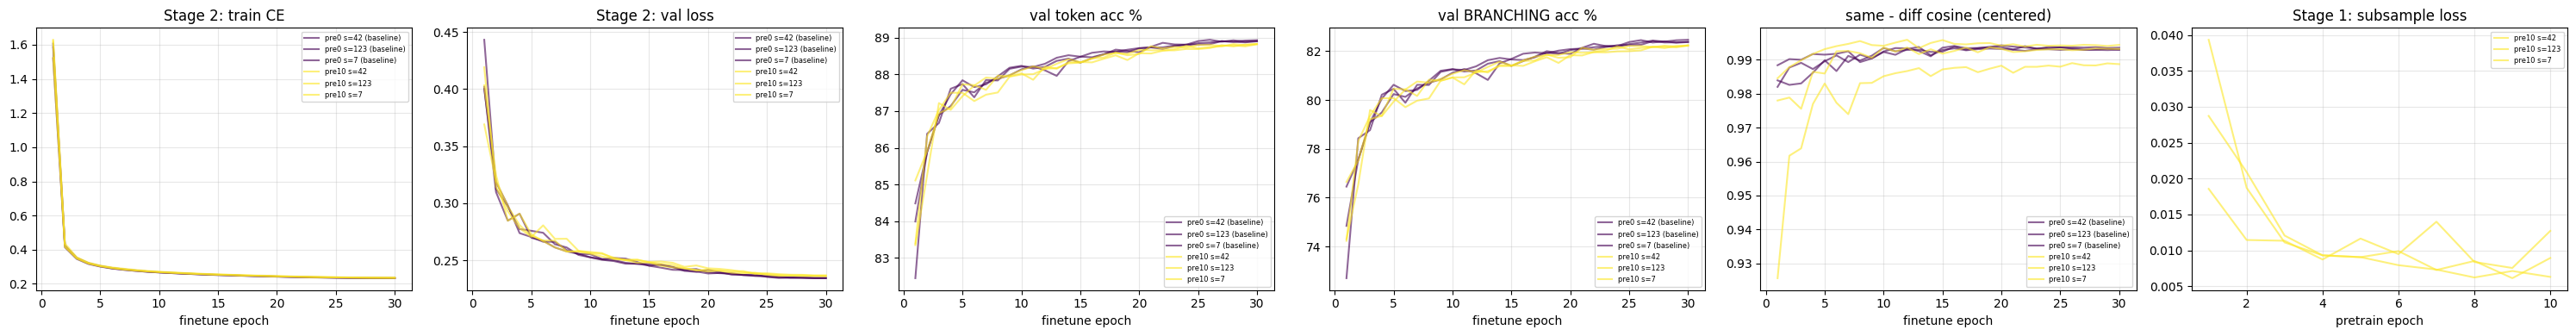

In [ ]:
import matplotlib.pyplot as plt


def load_history(pretrain_epochs, seed):
    p = run_paths(pretrain_epochs, seed)['history']
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)


_fig, _ax = plt.subplots(1, 6, figsize=(30, 4))
_cmap = plt.get_cmap('viridis')
_col = {p: _cmap(i / max(len(PRETRAIN_EPOCHS_VALUES) - 1, 1))
        for i, p in enumerate(PRETRAIN_EPOCHS_VALUES)}

for _p in PRETRAIN_EPOCHS_VALUES:
    for _s in SEEDS:
        _h = load_history(_p, _s)
        if not _h:
            continue
        _lbl = f'pre{_p} s={_s}' + (' (baseline)' if _p == 0 else '')
        for _i, _key, _scale in ((0, 'train', 1), (1, 'val', 1),
                                 (2, 'val_acc', 100), (3, 'val_branch_acc', 100),
                                 (4, 'val_gap_centered', 1),
                                 (5, 'pretrain_subsample', 1)):
            _series = _h.get(_key) or []
            if _series:
                _ax[_i].plot(range(1, len(_series) + 1),
                             [v * _scale for v in _series],
                             color=_col[_p], alpha=.6, label=_lbl)

for _i, _title in enumerate(['Stage 2: train CE', 'Stage 2: val loss',
                             'val token acc %', 'val BRANCHING acc %',
                             'same - diff cosine (centered)',
                             'Stage 1: subsample loss']):
    _ax[_i].set_title(_title)
    _ax[_i].set_xlabel('pretrain epoch' if _i == 5 else 'finetune epoch')
    _ax[_i].grid(alpha=.3)
    _ax[_i].legend(fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
%load_ext tensorboard
%tensorboard --logdir {LOCAL_LOG_ROOT}

<IPython.core.display.Javascript object>

### Inspect predictions

In [ ]:
def to_infix(prefix_str):
    """Prefix string -> infix via SymPy. Returns (infix_str, error_msg)."""
    try:
        expr, _ = prefix_to_sympy(prefix_str)
        return str(expr), None
    except Exception as e:
        return None, str(e)


def inspect_run(pretrain_epochs, seed, n_show=10):
    """Show per-equation predictions from a run's metrics.json."""
    p = run_paths(pretrain_epochs, seed)['metrics']
    if not p.exists():
        print(f'pretrain_{pretrain_epochs}/seed_{seed}: no metrics.json')
        return
    with open(p) as f:
        metrics = json.load(f)

    print(f'\n{"=" * 80}')
    print(f'pretrain_{pretrain_epochs}/seed_{seed} | '
          f'exact={metrics["greedy_exact_match"] * 100:.1f}% | '
          f'equiv={metrics["greedy_algebraic_equiv"] * 100:.1f}% | '
          f'val_branch_acc={metrics["best_val_branch_acc"] * 100:.1f}%')
    print(f'{"=" * 80}')

    details = metrics.get('details', [])
    for i, d in enumerate(details[:n_show]):
        gt_infix, _ = to_infix(d['gt'])
        pred_infix, pred_err = to_infix(d['pred'])
        r2 = f'{d["r2"]:.4f}' if d['r2'] is not None else 'N/A'
        status = ('EXACT' if d['exact'] else 'EQUIV' if d.get('equiv')
                  else 'PARSEABLE' if d.get('parseable') else 'UNPARSEABLE')
        print(f'\n── [{i}] {status} | R²={r2} ──')
        print(f'  GT:   {gt_infix}')
        if pred_err is None:
            print(f'  Pred: {pred_infix}')
        else:
            print(f'  Pred: PARSE FAILED ({pred_err})')
            print(f'        {d["pred"]}')

    print(f'\n  Total {len(details)} | '
          f'exact {sum(d["exact"] for d in details)} | '
          f'equiv {sum(1 for d in details if d.get("equiv"))} | '
          f'unparseable {sum(1 for d in details if not d.get("parseable", True))}')


for _p in PRETRAIN_EPOCHS_VALUES:
    inspect_run(_p, SEEDS[0], n_show=10)


pretrain_0/seed_42 | exact=0.0% | equiv=35.8% | val_branch_acc=82.4%

── [0] EQUIV | R²=1.0000 ──
  GT:   c_0*(c_1 + c_2*x1)*exp(c_3*(c_4 + x1)**2)
  Pred: c_0*(c_7 + c_8*x1**2 + c_9*x1)*exp(c_10*(c_11 + x1)**2)/(c_1 + (c_2 + c_3*x1**4 + c_4*x1**3 + c_5*x1**2 + c_6*x1)**2)

── [1] EQUIV | R²=1.0000 ──
  GT:   c_0 + c_1*x1 + c_2*x1**3 + c_3*x1**2 + c_4*(c_8 + c_9*x1)/(c_5 + (c_6 + c_7*x1)**2)
  Pred: c_0 + c_1*x1**2 + c_2*x1 + c_3*x1**3 + c_4*sin(c_7 + c_8*x1)/(c_5 + c_6*x1**2) + c_9*cos(c_12 + c_13*x1)/(c_10 + c_11*x1**2)

── [2] PARSEABLE | R²=0.8517 ──
  GT:   c_0*sqrt(c_1 + (c_2 + c_3*x1**2 + c_4*x1**4 + c_5*x1 + c_6*x1**3)**2)*cos(c_7 + c_8*x1)**3
  Pred: c_0*(c_1 + c_2*x1**3 + c_3*x1**4 + c_4*x1**2 + c_5*x1)*sin(c_6 + 4*x1)

── [3] EQUIV | R²=1.0000 ──
  GT:   c_0*exp(c_1*x1**2)*sinh(c_2*x1)
  Pred: c_0*exp(c_1*(c_2 + x1)**2) + c_3*exp(c_4*x1**2)*sinh(c_5*x1) + c_6*sin(c_10*x1 + c_9)/(c_7 + c_8*x1**2)

── [4] EQUIV | R²=0.9994 ──
  GT:   c_0*(c_5 + c_6*x1 + c_7*x1**2)/(c_1 + (c_2

## Does pretraining solve a SUPERSET of the baseline, or a different set?

The aggregate gap cannot tell a **nested** gain (everything the baseline
solves, plus more) from a **rotation** (different sets of similar size, with
the headline being the residue of a much larger churn). Only the discordant
examples carry information, which is McNemar's test. Reads the per-example
`details` already in every `metrics.json` — nothing is re-run.

In [ ]:
_matrix = load_run_matrix(LOCAL_CHECKPOINT_ROOT, PRETRAIN_EPOCHS_VALUES, SEEDS)
_lo, _hi = min(PRETRAIN_EPOCHS_VALUES), max(PRETRAIN_EPOCHS_VALUES)

AGREEMENT = {}
for _metric in ('equiv', 'r2>0.9', 'exact'):
    if not (_matrix.get(_lo) and _matrix.get(_hi)):
        print(f'skipping {_metric}: need both arms evaluated')
        continue
    AGREEMENT[_metric] = compare_runs(
        _matrix[_lo], _matrix[_hi], metric=_metric,
        name_a=f'pretrain_{_lo}', name_b=f'pretrain_{_hi}')
    print('\n' + '=' * 78 + '\n')

=== equiv: pretrain_0 vs pretrain_10 over 3 seeds ===

    seed    both   only_a   only_b    net   nested         p
       7    1030      150      150     +0    False         1
      42    1016      190      160    -30    False     0.121
     123    1031      143      145     +2    False     0.953

pretrain_10 wins the discordant count in 1/3 seeds; nested in 0/3

POOLED
equiv: pretrain_0 3560/10113 (35.20%) vs pretrain_10 3532/10113 (34.93%)
  both correct        : 3077
  only pretrain_0    : 483
  only pretrain_10   : 455
  neither             : 6098
  net                 : -28
  discordant          : 938 (9.28% of the test set)
  McNemar exact p     : 0.378
  -> NOT nested: pretrain_10 lost 483 that pretrain_0 solved. Churn = 33.5x the net gain, so the arms differ on 938 examples to move -28.


=== r2>0.9: pretrain_0 vs pretrain_10 over 3 seeds ===

    seed    both   only_a   only_b    net   nested         p
       7    2319      154      137    -17    False     0.348
      42    2

## Does the advantage grow, shrink, or appear late?

`SYMBOLIC_EVAL_EVERY` records `equiv` and `R2>0.9` on a fixed validation
prefix during training, so the effect is a trajectory rather than one
end-of-run number.

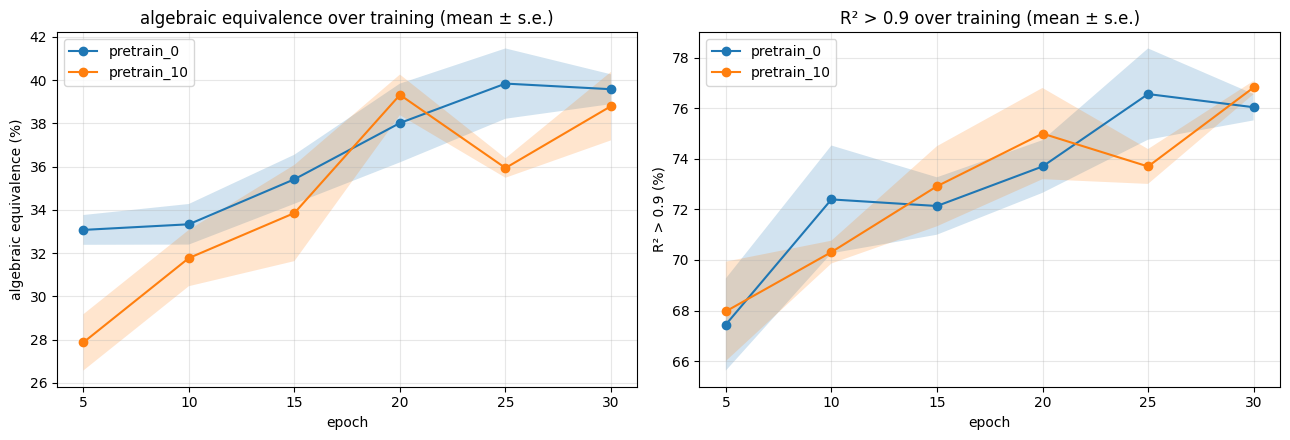

In [ ]:
_have_sym = any('sym_equiv' in (load_history(_p, _s) or {})
                for _p in PRETRAIN_EPOCHS_VALUES for _s in SEEDS)

if not _have_sym:
    print('No mid-training symbolic history — needs a run with '
          'SYMBOLIC_EVAL_EVERY > 0.')
else:
    _fig, _axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for _ax, _key, _label in ((_axes[0], 'sym_equiv', 'algebraic equivalence'),
                              (_axes[1], 'sym_r2_above_0.9', 'R² > 0.9')):
        for _p in PRETRAIN_EPOCHS_VALUES:
            _curves, _ep = [], None
            for _s in SEEDS:
                _h = load_history(_p, _s)
                if not _h or _key not in _h:
                    continue
                _curves.append(_h[_key])
                _ep = _h.get('sym_epoch')
            if not _curves:
                continue
            _n = min(len(c) for c in _curves)
            _arr = np.array([c[:_n] for c in _curves])
            _mean = _arr.mean(axis=0) * 100
            _se = (_arr.std(axis=0, ddof=1) / np.sqrt(len(_arr)) * 100
                   if len(_arr) > 1 else np.zeros(_n))
            _x = (_ep or list(range(1, _n + 1)))[:_n]
            _ax.plot(_x, _mean, marker='o', label=f'pretrain_{_p}')
            _ax.fill_between(_x, _mean - _se, _mean + _se, alpha=0.2)
        _ax.set_xlabel('epoch')
        _ax.set_ylabel(f'{_label} (%)')
        _ax.set_title(f'{_label} over training (mean ± s.e.)')
        _ax.legend()
        _ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()